# Design simulation

## How to read the statistics

RMSE is the primary utility-recovery metric and lower values are better. Pearson correlation is a scale-free diagnostic and higher values are better. The intervals are Monte Carlo 95% intervals over three simulation replicates, not participant-level confidence intervals.

## Simulation assumptions

The fixed 100-item bank has evenly spaced latent ranks. Each policy receives the same balanced 500-pair graph and matched observation budget. The matching scenario follows the learner likelihood. The misspecified scenario adds lapses, left bias, and weaker choice consistency. There is no dropout or participant cost model. The campaign uses 128 bootstrap refits for tractability; a separate operational benchmark exercises the deployed 2,048-refit setting.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

%config InlineBackend.figure_formats = ["svg"]
root = Path.cwd()
while not (root / "experiment.py").exists():
    root = root.parent
results = pd.read_csv(root / "audit/simulate/design/results.csv")
rmse = results[results["analysis_id"] == "rmse"].copy()
display(rmse[["scenario_id", "policy", "n_observations", "estimate", "mc95_lower", "mc95_upper", "adaptive_minus_random_rmse"]])

,scenario_id,policy,n_observations,estimate,mc95_lower,mc95_upper,adaptive_minus_random_rmse
0,matching,adaptive,100,1.080838,1.033190,1.128487,-0.068156
4,matching,random,100,1.148994,1.127647,1.170341,NaN
8,misspecified,adaptive,100,1.090010,1.065674,1.114347,-0.091402
12,misspecified,random,100,1.181412,1.155024,1.207800,NaN
16,matching,adaptive,300,1.099899,1.095255,1.104544,0.046829
20,matching,random,300,1.053071,1.035659,1.070482,NaN
24,misspecified,adaptive,300,1.229775,1.168983,1.290566,0.085171
28,misspecified,random,300,1.144604,1.108435,1.180772,NaN


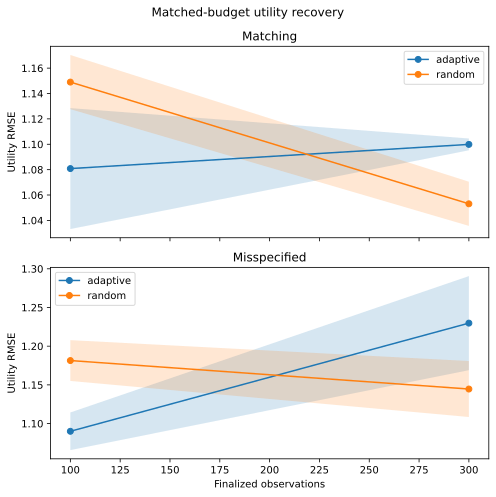

,scenario_id,policy,n_observations,estimate
3,matching,adaptive,100,0.000282
7,matching,random,100,0.000001
11,misspecified,adaptive,100,0.000283
15,misspecified,random,100,0.000001
19,matching,adaptive,300,0.000236
23,matching,random,300,0.000001
27,misspecified,adaptive,300,0.000236
31,misspecified,random,300,0.000001


In [2]:
fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
for axis, (scenario, frame) in zip(axes, rmse.groupby("scenario_id", sort=True)):
    for policy, policy_frame in frame.groupby("policy"):
        policy_frame = policy_frame.sort_values("n_observations")
        axis.plot(policy_frame["n_observations"], policy_frame["estimate"], marker="o", label=policy)
        axis.fill_between(policy_frame["n_observations"], policy_frame["mc95_lower"], policy_frame["mc95_upper"], alpha=0.18)
    axis.set(title=scenario.capitalize(), ylabel="Utility RMSE")
    axis.legend()
axes[-1].set_xlabel("Finalized observations")
fig.suptitle("Matched-budget utility recovery")
fig.tight_layout()
plt.show()

selection = results[results["analysis_id"] == "mean_selection_seconds"]
display(selection[["scenario_id", "policy", "n_observations", "estimate"]])

## Decision

The prespecified criterion is not met. At 300 observations, adaptive-minus-random RMSE is positive in both scenarios, meaning the adaptive policy performs worse. This negative result is retained without post-hoc policy tuning. The implementation is useful for infrastructure dogfooding, but a real study should use the random baseline or prespecify and validate a revised objective before deployment.